In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import textstat
from tqdm import tqdm

# integrating tqdm with pandas (to see a progress bar)
tqdm.pandas()

# seeing at most 100 columns
pd.set_option('display.max_columns', 100)

In [3]:
df = pd.read_csv("spotify_millsongdata.csv")
print(df.head())
print(df.info())

  artist                   song                                        link  \
0   ABBA  Ahe's My Kind Of Girl  /a/abba/ahes+my+kind+of+girl_20598417.html   
1   ABBA       Andante, Andante       /a/abba/andante+andante_20002708.html   
2   ABBA         As Good As New        /a/abba/as+good+as+new_20003033.html   
3   ABBA                   Bang                  /a/abba/bang_20598415.html   
4   ABBA       Bang-A-Boomerang      /a/abba/bang+a+boomerang_20002668.html   

                                                text  
0  Look at her face, it's a wonderful face  \r\nA...  
1  Take it easy with me, please  \r\nTouch me gen...  
2  I'll never know why I had to go  \r\nWhy I had...  
3  Making somebody happy is a question of give an...  
4  Making somebody happy is a question of give an...  
<class 'pandas.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   artist  57650 non-null 

In [4]:
print("1. Step: Sentiment Analysis (Sentiment Analysis)")
# We are downloading and preparing the VADER emotion analysis tool of the NLTK library
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# We take the 'compound' score of the lyrics (between -1 and Dec 1)
df['sentiment_score'] = df['text'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])

1. Step: Sentiment Analysis (Sentiment Analysis)


100%|███████████████████████████████████████████████████████████████████████████| 57650/57650 [02:40<00:00, 359.24it/s]


In [5]:
df.head(20)

,artist,song,link,text,sentiment_score
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA...",0.9587
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen...",0.9877
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...,0.9986
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...,0.9971
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...,0.9974
5,ABBA,Burning My Bridges,/a/abba/burning+my+bridges_20003011.html,"Well, you hoot and you holler and you make me ...",-0.9382
6,ABBA,Cassandra,/a/abba/cassandra_20002811.html,Down in the street they're all singing and sho...,-0.9956
7,ABBA,Chiquitita,/a/abba/chiquitita_20002978.html,"Chiquitita, tell me what's wrong \r\nYou're e...",-0.9640
8,ABBA,Crazy World,/a/abba/crazy+world_20003013.html,I was out with the morning sun \r\nCouldn't s...,-0.2324
9,ABBA,Crying Over You,/a/abba/crying+over+you_20177611.html,I'm waitin' for you baby \r\nI'm sitting all ...,0.6904


<Axes: >

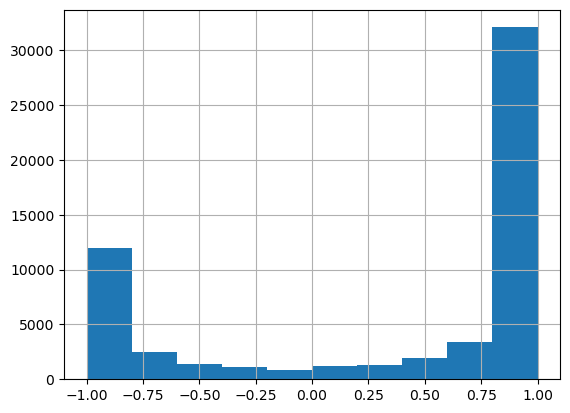

In [6]:
df['sentiment_score'].hist()

In [7]:
print("\n2. Step: Cognitive Analysis (Flesch-Kincaid Readability)")
# we calculate the Flesch-Kincaid convenience score using the textstat library
# Note: This metric measures linguistic complexity based on word and sentence lengths.
df['readability_score'] = df['text'].progress_apply(lambda x: textstat.flesch_reading_ease(str(x)))


2. Step: Cognitive Analysis (Flesch-Kincaid Readability)


100%|██████████████████████████████████████████████████████████████████████████| 57650/57650 [00:33<00:00, 1746.50it/s]


In [8]:
df.head()

,artist,song,link,text,sentiment_score,readability_score
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA...",0.9587,80.670118
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen...",0.9877,-164.441923
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...,0.9986,-209.087308
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...,0.9971,-106.991000
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...,0.9974,-106.080455


<Axes: >

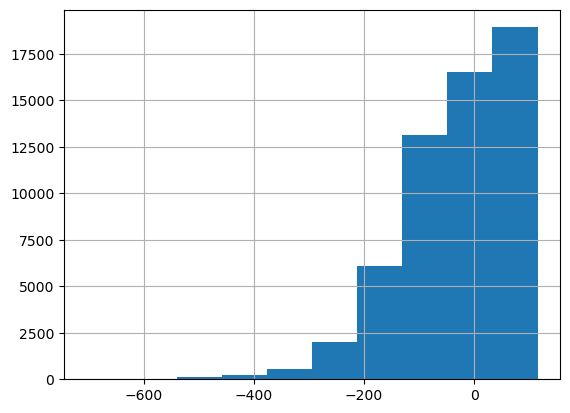

In [9]:
df['readability_score'].hist()

In [10]:
print("\n3. Step: Semantic Analysis (TF-IDF + LSA)")

# Creating the TF-IDF Matrix (Stop words: we eliminate unnecessary words in English)
tfidf = TfidfVectorizer(stop_words='english', max_features=4000)
tfidf_matrix = tfidf.fit_transform(df['text'])


3. Step: Semantic Analysis (TF-IDF + LSA)


In [16]:
print(tfidf_matrix.shape)
print(tfidf_matrix)

(57650, 4000)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2652275 stored elements and shape (57650, 4000)>
  Coords	Values
  (0, 2040)	0.15771885332069646
  (0, 1133)	0.17445927982642043
  (0, 3920)	0.1558100622794229
  (0, 2148)	0.13972555276190352
  (0, 3239)	0.14500093212927645
  (0, 3819)	0.06258247416962057
  (0, 3175)	0.1607482779450849
  (0, 2982)	0.15622399946450968
  (0, 2076)	0.14678923300182198
  (0, 1205)	0.19311647261326265
  (0, 1834)	0.19368267216262477
  (0, 1866)	0.4381657466562166
  (0, 1410)	0.34045913556488006
  (0, 2107)	0.2142299713243552
  (0, 1196)	0.14191747299673468
  (0, 1230)	0.22921941499818005
  (0, 233)	0.1837142045320821
  (0, 310)	0.2062170910370703
  (0, 1954)	0.27765272684800724
  (0, 3776)	0.0967334990694212
  (0, 2441)	0.15440859145165817
  (0, 1649)	0.16298942795709134
  (0, 1531)	0.09212767492750233
  (0, 2023)	0.054033639280263064
  (0, 3779)	0.12175080208384452
  :	:
  (57649, 1968)	0.26798746207522794
  (57649, 1892)	0.0497107

In [17]:
# Latent Semantic Analysis (LSA) - Dimension Reduction
n_components = 10
lsa = TruncatedSVD(n_components=n_components, random_state=42)
lsa_matrix = lsa.fit_transform(tfidf_matrix)

# Adding LSA results as columns to the main DataFrame
lsa_columns = [f'lsa_dim_{i+1}' for i in range(n_components)]
df_lsa = pd.DataFrame(lsa_matrix, columns=lsa_columns, index=df.index)
df = pd.concat([df, df_lsa], axis=1)

In [18]:
df.head()

,artist,song,link,text,sentiment_score,readability_score,lsa_dim_1,lsa_dim_2,lsa_dim_3,lsa_dim_4,lsa_dim_5,lsa_dim_6,lsa_dim_7,lsa_dim_8,lsa_dim_9,lsa_dim_10
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA...",0.9587,80.670118,0.179363,-0.039215,-0.038544,0.011924,-0.027334,-0.007173,-0.017545,0.021840,0.026798,0.025689
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen...",0.9877,-164.441923,0.248796,-0.058623,0.028269,0.049282,0.087005,0.044714,0.056557,0.027440,-0.011759,0.159406
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...,0.9986,-209.087308,0.111644,0.034151,-0.008292,-0.008763,-0.030682,-0.039024,0.005575,-0.005585,0.003724,0.008045
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...,0.9971,-106.991000,0.084317,0.083780,0.007105,0.018211,0.006375,-0.003141,0.000132,-0.026299,0.025564,-0.008865
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...,0.9974,-106.080455,0.105839,0.099842,0.005948,0.020435,0.007001,-0.006190,-0.000013,-0.031668,0.029629,-0.010322


In [19]:
print("\n4. Step: Data Standardization")
features_to_scale = ['sentiment_score', 'readability_score'] + lsa_columns

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_to_scale])

# Adding scaled data as new columns (prefixing them with 'scaled_')
scaled_columns = [f'scaled_{col}' for col in features_to_scale]
df_scaled = pd.DataFrame(scaled_features, columns=scaled_columns, index=df.index)
df = pd.concat([df, df_scaled], axis=1)


4. Step: Data Standardization


In [20]:
df.head()

,artist,song,link,text,sentiment_score,readability_score,lsa_dim_1,lsa_dim_2,lsa_dim_3,lsa_dim_4,lsa_dim_5,lsa_dim_6,lsa_dim_7,lsa_dim_8,lsa_dim_9,lsa_dim_10,scaled_sentiment_score,scaled_readability_score,scaled_lsa_dim_1,scaled_lsa_dim_2,scaled_lsa_dim_3,scaled_lsa_dim_4,scaled_lsa_dim_5,scaled_lsa_dim_6,scaled_lsa_dim_7,scaled_lsa_dim_8,scaled_lsa_dim_9,scaled_lsa_dim_10
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA...",0.9587,80.670118,0.179363,-0.039215,-0.038544,0.011924,-0.027334,-0.007173,-0.017545,0.021840,0.026798,0.025689,0.752212,1.091850,0.005303,-0.333973,-0.399009,0.018709,-0.313987,-0.076898,-0.325704,0.271280,0.437332,0.385110
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen...",0.9877,-164.441923,0.248796,-0.058623,0.028269,0.049282,0.087005,0.044714,0.056557,0.027440,-0.011759,0.159406,0.788337,-1.309012,0.855849,-0.551372,0.424427,0.506490,1.309825,0.687473,0.808512,0.360330,-0.176021,2.554277
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...,0.9986,-209.087308,0.111644,0.034151,-0.008292,-0.008763,-0.030682,-0.039024,0.005575,-0.005585,0.003724,0.008045,0.801916,-1.746312,-0.824255,0.487844,-0.026169,-0.251391,-0.361526,-0.546101,0.028177,-0.164845,0.070274,0.098885
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...,0.9971,-106.991000,0.084317,0.083780,0.007105,0.018211,0.006375,-0.003141,0.000132,-0.026299,0.025564,-0.008865,0.800047,-0.746283,-1.159003,1.043764,0.163598,0.100803,0.164747,-0.017507,-0.055134,-0.494257,0.417706,-0.175422
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...,0.9974,-106.080455,0.105839,0.099842,0.005948,0.020435,0.007001,-0.006190,-0.000013,-0.031668,0.029629,-0.010322,0.800421,-0.737364,-0.895359,1.223688,0.149335,0.129833,0.173634,-0.062417,-0.057362,-0.579629,0.482372,-0.199057


In [21]:
df.to_csv("spotify_millsongdata_processed.csv")